In [49]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc
from cartopy.util import add_cyclic_point


logger = logging.getLogger(__name__)

In [25]:
run plot_tools.ipynb

In [74]:
def make_map(variable, lsm, ssp, landuse, axs, axi, lon, lats, input_array,mask_between):
  
    cbarticks = np.arange(-4.0,4.5,0.5)
    colormap='BrBG'
    #mapdata,lons = add_cyclic_point(input_array,lon)
    
    if lsm=='JSBACH':
        latSouth=3
        latNorth=79
        ilatSouth=3
        ilatNorth=79
        clon=0.0
        transform_first=False        
    elif lsm=='JULES':
        latSouth=16 #north of 58S
        latNorth=88 #south of 86N
        ilatSouth=16 
        ilatNorth=88 
        clon=180
        transform_first=False
    elif lsm=='CLM':
        latSouth=17
        latNorth=92
        ilatSouth=17
        ilatNorth=92
        clon=0.0
        transform_first=False
    elif lsm=='ORCHIDEE':
        latSouth=16
        latNorth=88
        clon=0.0 
        lons, lats = np.meshgrid(lons, lats)
        ilatSouth=0
        ilatNorth=72
        transform_first=True

    if variable=='rn':
        if landuse=='No LUC':
            contourmin = -15.0
            contourmax = 15.0
            cbarticks = np.arange(-15.0,18.0,3.0)        
        else:
            contourmin = -1.0
            contourmax = 1.0
            cbarticks = np.arange(-1.0,1.1,0.1)                    
    elif variable=='hfss' or variable=='hfls':
        if landuse=='No LUC':
            contourmin = -40.0
            contourmax = 40.0
            cbarticks = np.arange(-40.0,44.0,4.0)         
        else:
            contourmin = -3.0
            contourmax = 3.0
            cbarticks = np.arange(-3.0,3.3,0.3)   
    elif variable=='hfg':
        if landuse=='No LUC':
            contourmin=-6.0
            contourmax=6.0
            cbarticks = np.arange(-6.0,8.0,2.0)
    elif variable=='rlus' or variable=='rlds' or variable=='rsus' or variable=='rsds':
        if landuse=='No LUC':
            contourmin=-30.0
            contourmax=35.0
            cbarticks = np.arange(-30.0,35.0,5.0) 
    elif variable=='LWnet' or variable=='SWnet':
        if landuse!='No LUC':
            contourmin = -1.0
            contourmax = 1.0
            cbarticks = np.arange(-1.0,1.1,0.1)
    elif variable=='TotalAlbedo':
        if landuse=='No LUC':
            contourmin = -0.5
            contourmax = 0.5
            cbarticks = np.arange(-0.5,0.55,0.05) 
        else:
            contourmin = -0.001
            contourmax = 0.001
            cbarticks = np.arange(-0.001,0.0011,0.0001) 
    else:
        contourmin=-20.
        contourmax=50.
    if mask_between:
        mask_between_threshold(input_array, 1.0e-2)

    cs=axs[axi].contourf(lon,lats,input_array, cbarticks,
                         cmap=colormap,extend='both', vmin=contourmin, vmax=contourmax, 
                         transform = ccrs.PlateCarree(central_longitude=clon),transform_first=transform_first
                         )              
    axs[axi].set_title(lsm+' '+ssp+' '+landuse)
    axs[axi].coastlines()

    return (cs)

In [51]:
def mask_between_threshold(cube, threshold):
    """Mask values between +/- a specific threshold value.

    Takes a value 'threshold' and masks off anything that is above
    it in the cube data. Values equal to the threshold are not masked.

    Parameters
    ----------
    cube: iris.cube.Cube
        iris cube to be thresholded.

    threshold: float
        threshold to be applied on input cube data.

    Returns
    -------
    iris.cube.Cube
        thresholded cube.
    """
    negative_threshold = -1 * threshold
    cube = np.ma.masked_inside(cube, negative_threshold, threshold)
    return cube


In [26]:
def get_global_biophys_delta(var,landuse,model,ssp,noluc_only):
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    path = '' 

    nclim = len(ESMS)
    
    if model=='jsbach':
     years = np.arange(2015,2100)
    else:
     years = np.arange(2015,2101)   
    nyears = len(years)
    nmonths= nyears*12

    land_fraction,lons,lats = get_lsm_data(model)
    nlat = len(lats)
    nlon = len(lons)
    weights = np.empty_like(land_fraction)
    bph_annual = np.zeros([3,nyears])
    map_2015 = np.zeros([3,nlat,nlon])
    map_2100 = np.zeros([3,nlat,nlon])    
    land_fraction = np.ma.masked_values(land_fraction, 0.0, True)
    if model!= 'jsbach':
        for kk in range(nlat):
            weights[kk,0:nlon] = np.cos(np.deg2rad(lats[kk])) * land_fraction[kk,0:nlon]
    else:
        for kk in range(nlat):
            weights[kk,0:nlon] = np.cos(np.deg2rad(lats[kk]))       
    weights_3d = np.stack([weights] * nyears)
    #print(weights_3d.shape)

    # 3 per SSP
    filenames = get_filenames(var,landuse,model,ssp)
    if model=='jules':
        filenames_noluc = get_filenames(var,'nolucbio',model,ssp)
    else:
        filenames_noluc = get_filenames(var,'noluc',model,ssp)
    model_i=0

    for fname in filenames:    
        print(fname)
        ncfile=Dataset(fname, 'r')
        mon_data = ncfile.variables[var]
        if model!='clm':
            try:
                mon_data = np.ma.masked_values(mon_data, mon_data.missing_value, True)
            except:
                mon_data = np.ma.masked_values(mon_data, mon_data._FillValue, True)
        else:
            #print('CLM before first mask:',np.min(mon_data),np.max(mon_data))
            mon_data = np.ma.masked_greater(mon_data, 1.0e30, True)   
            #print('CLM after first mask:',np.min(mon_data),np.max(mon_data))
              
        ncfile2=Dataset(filenames_noluc[model_i],'r')
        noluc_data = ncfile2.variables[var]
        if model!='clm':
            try:
                noluc_data = np.ma.masked_values(noluc_data, noluc_data.missing_value, True)
            except:
                noluc_data = np.ma.masked_values(noluc_data, noluc_data._FillValue, True)        
        else:
            noluc_data = np.ma.masked_greater(noluc_data, 1.0e30, True)   
        if noluc_only:
            calc_delta=False
        else:    
            calc_delta=True
        monthly_delta = get_lsm_fracs(mon_data,noluc_data,model,ESMS[model_i],ssp,landuse,calc_delta,noluc_only)
        print(np.min(monthly_delta),np.max(monthly_delta))
        annual_delta = np.mean(monthly_delta.reshape((nyears,12,nlat,nlon)),axis=1)
        
        bph_annual[model_i,:] = np.mean(annual_delta*weights_3d,axis=(1,2))
        
        map_2015[model_i,:,:] = np.mean(annual_delta[0:20,:,:],axis=0)*land_fraction
        map_2100[model_i,:,:] = np.mean(annual_delta[nyears-20:,:,:],axis=0)*land_fraction
        #print(np.mean(annual_delta[0:20,:,:],axis=0))
        #print(map_2015[model_i,:,:])
        model_i+=1   
        del(monthly_delta, annual_delta)
    
    #print(model,np.mean(map_2015,axis=0),np.mean(map_2100,axis=0))
    #print(np.mean(bph_annual,axis=0))

    return np.mean(bph_annual,axis=0), np.mean(map_2015,axis=0), np.mean(map_2100,axis=0)

In [27]:
#SET UP ALL OF THE VARIABLES, DICTIONARIES, ETC

MODELS=['jules','clm','jsbach']
LANDUSES=['agtobio','nattobio']
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']
VARIABLES=['rn','hfss','hfls',\
           'hfg','rlds','rlus',\
           'rsds','rsus','TotalAlbedo','SWnet','LWnet']
YEARS=['2015','2100']

#How close can we get to energy balance for each model:
# X means it's missing
#        Rn    =   SH +    L + g          = SWdown  -  Swup      + LWdown - LWup
#JULES   rn    = hfss + hfls + X          = TotalAlbedo*(SWdown) + X      - X
#JSBACH  rn    = sfls + hfls + fGoundHeat = rsds    - rsus       + rlds   - X
#CLM     X     = hfss + rfls + hfg        = rsds    - rsus       + rlds   - rlus
#jsbach: sfls = 'surface upward sensible heat flux'



all_landuse=['noluc_agtobio','noluc_nattobio','agtobio','nattobio']
DELTA_GLOBAL = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for lsm_mod in MODELS} 
                    for var in VARIABLES}

GLOBAL_MEAN = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in all_landuse} for lsm_mod in MODELS} 
                    for var in VARIABLES}
MAP_DELTA_2015 = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                  for landuse in all_landuse} for lsm_mod in MODELS}
                  for var in VARIABLES}
MAP_DELTA_2100 = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                  for landuse in all_landuse} for lsm_mod in MODELS}
                  for var in VARIABLES}
MAP_2015 = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                  for landuse in all_landuse} for lsm_mod in MODELS}
                  for var in VARIABLES}
MAP_2100 = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                  for landuse in all_landuse} for lsm_mod in MODELS}
                  for var in VARIABLES}

landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}

variable_exists = {var: {lsm_mod: [True] for lsm_mod in MODELS} for var in VARIABLES}
variable_exists['TotalAlbedo']['jsbach'] = False
variable_exists['TotalAlbedo']['clm'] = False
variable_exists['rn']['clm'] = False
variable_exists['hfg']['jules'] = False
variable_exists['rlus']['jules'] = False
variable_exists['rsus']['jules'] = False
variable_exists['rlus']['jsbach'] = False
variable_exists['rlds']['jules'] = False

plotvar = {var: [False] for var in VARIABLES}
plotvar['TotalAlbedo'] = True
plotvar['SWnet'] = True
plotvar['LWnet'] = True
plotvar['rn'] = True
plotvar['hfss'] = True
plotvar['hfls'] = True

colors = {model: [] for model in MODELS}
colors['jules'] = '#F97306'
colors['clm'] = '#C5C9C7'
colors['jsbach'] = '#D1B26F'
#colors['orchidee'] = '#A9561E'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {ssp: [] for ssp in SSPS}
linestyles['ssp126'] = '-'
linestyles['ssp370'] = '--'

In [28]:
# ENERGY FLUXES FIRST:
# hfss, hfls, hfg, rn

for var in VARIABLES[0:4]:
    for model in MODELS:
        if variable_exists[var][model]:
            if model=='jules' and var=='hfls':
                varname='fHeatLatent'
            elif model=='jules' and var=='hfss':
                varname='fHeatSensible'
            elif model=='jsbach' and var=='hfss':
                varname='sfls'
            elif model=='jsbach' and var=='hfg':
                varname='fGroundHeat'
            else:
                varname=var            
            #print('Get ',var,model)
            for landuse in LANDUSES:
                for ssp in SSPS:
                    pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_delta'+var+'_'+landuse+'_BEmasked.pkl',\
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_delta'+var+'_2015-2034_'+landuse+'_BEmasked.pkl', \
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_delta'+var+'_2081-2100_'+landuse+'_BEmasked.pkl']
                    # First get the no land use outputs, masked according to the landuse scenario
                    if Path(pickle_file[1]).is_file():
                        #print(landuse,'read pickle files',pickle_file[0])
                        with open(Path(pickle_file[0]), 'rb') as f1:
                            ts_output = pickle.load(f1)
                        with open(Path(pickle_file[1]), 'rb') as f2:
                            t0_output = pickle.load(f2)
                        with open(Path(pickle_file[2]), 'rb') as f3:
                            t1_output = pickle.load(f3)
                        DELTA_GLOBAL[var][model][landuse][ssp] = ts_output
                        MAP_DELTA_2015[var][model][landuse][ssp] = t0_output
                        MAP_DELTA_2100[var][model][landuse][ssp] = t1_output
                        del(ts_output, t0_output, t1_output)
                    else:
                        noluc_only=False
                        DELTA_GLOBAL[var][model][landuse][ssp],MAP_DELTA_2015[var][model][landuse][ssp],\
                        MAP_DELTA_2100[var][model][landuse][ssp] = \
                                 get_global_biophys_delta(varname,landuse,model,ssp,noluc_only)                 
                        with open(Path(pickle_file[0]), 'wb') as f1:
                            pickle.dump(DELTA_GLOBAL[var][model][landuse][ssp], f1)
                        with open(Path(pickle_file[1]), 'wb') as f2:
                            pickle.dump(MAP_DELTA_2015[var][model][landuse][ssp], f2)
                        with open(Path(pickle_file[2]), 'wb') as f3:
                            pickle.dump(MAP_DELTA_2100[var][model][landuse][ssp], f3)                            
                    print('Done with',var,model,landuse,ssp)

for ssp in SSPS:
    for landuse in LANDUSES:
        DELTA_GLOBAL['hfg']['jules'][landuse][ssp] = DELTA_GLOBAL['rn']['jules'][landuse][ssp] -\
                                                    DELTA_GLOBAL['hfls']['jules'][landuse][ssp] -\
                                                    DELTA_GLOBAL['hfss']['jules'][landuse][ssp]
        DELTA_GLOBAL['rn']['clm'][landuse][ssp] = DELTA_GLOBAL['hfg']['clm'][landuse][ssp] +\
                                                    DELTA_GLOBAL['hfls']['clm'][landuse][ssp] +\
                                                    DELTA_GLOBAL['hfss']['clm'][landuse][ssp]
variable_exists['rn']['clm'] = True
variable_exists['hfg']['jules'] = True

Done with rn jules agtobio ssp126
Done with rn jules agtobio ssp370
Done with rn jules nattobio ssp126
Done with rn jules nattobio ssp370
Done with rn jsbach agtobio ssp126
Done with rn jsbach agtobio ssp370
Done with rn jsbach nattobio ssp126
Done with rn jsbach nattobio ssp370
Done with hfss jules agtobio ssp126
Done with hfss jules agtobio ssp370
Done with hfss jules nattobio ssp126
Done with hfss jules nattobio ssp370
Done with hfss clm agtobio ssp126
Done with hfss clm agtobio ssp370
Done with hfss clm nattobio ssp126
Done with hfss clm nattobio ssp370
Done with hfss jsbach agtobio ssp126
Done with hfss jsbach agtobio ssp370
Done with hfss jsbach nattobio ssp126
Done with hfss jsbach nattobio ssp370
Done with hfls jules agtobio ssp126
Done with hfls jules agtobio ssp370
Done with hfls jules nattobio ssp126
Done with hfls jules nattobio ssp370
Done with hfls clm agtobio ssp126
Done with hfls clm agtobio ssp370
Done with hfls clm nattobio ssp126
Done with hfls clm nattobio ssp370
Do

In [29]:
# RADIATIVE FLUXES NEXT:
# rsds, rsus, rlds, rlus

for var in VARIABLES[4:9]:
    for model in MODELS:
        if variable_exists[var][model]:
            varname=var            
            #print('Get ',var,model)
            for landuse in LANDUSES:
                for ssp in SSPS:
                    pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_delta'+var+'_'+landuse+'_BEmasked.pkl',\
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_delta'+var+'_2015-2034_'+landuse+'_BEmasked.pkl', \
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_delta'+var+'_2081-2100_'+landuse+'_BEmasked.pkl']
                    # First get the no land use outputs, masked according to the landuse scenario
                    if Path(pickle_file[1]).is_file():
                        #print(landuse,'read pickle files',pickle_file[0])
                        with open(Path(pickle_file[0]), 'rb') as f1:
                            ts_output = pickle.load(f1)
                        with open(Path(pickle_file[1]), 'rb') as f2:
                            t0_output = pickle.load(f2)
                        with open(Path(pickle_file[2]), 'rb') as f3:
                            t1_output = pickle.load(f3)
                        DELTA_GLOBAL[var][model][landuse][ssp] = ts_output
                        MAP_DELTA_2015[var][model][landuse][ssp] = t0_output
                        MAP_DELTA_2100[var][model][landuse][ssp] = t1_output
                        del(ts_output, t0_output, t1_output)
                    else:
                        noluc_only=False
                        DELTA_GLOBAL[var][model][landuse][ssp],MAP_DELTA_2015[var][model][landuse][ssp],\
                        MAP_DELTA_2100[var][model][landuse][ssp] = \
                                 get_global_biophys_delta(varname,landuse,model,ssp,noluc_only)                 
                        with open(Path(pickle_file[0]), 'wb') as f1:
                            pickle.dump(DELTA_GLOBAL[var][model][landuse][ssp], f1)
                        with open(Path(pickle_file[1]), 'wb') as f2:
                            pickle.dump(MAP_DELTA_2015[var][model][landuse][ssp], f2)
                        with open(Path(pickle_file[2]), 'wb') as f3:
                            pickle.dump(MAP_DELTA_2100[var][model][landuse][ssp], f3)                            
                    print('Done with',var,model,landuse,ssp)



Done with rlds clm agtobio ssp126
Done with rlds clm agtobio ssp370
Done with rlds clm nattobio ssp126
Done with rlds clm nattobio ssp370
Done with rlds jsbach agtobio ssp126
Done with rlds jsbach agtobio ssp370
Done with rlds jsbach nattobio ssp126
Done with rlds jsbach nattobio ssp370
Done with rlus clm agtobio ssp126
Done with rlus clm agtobio ssp370
Done with rlus clm nattobio ssp126
Done with rlus clm nattobio ssp370
Done with rsds jules agtobio ssp126
Done with rsds jules agtobio ssp370
Done with rsds jules nattobio ssp126
Done with rsds jules nattobio ssp370
Done with rsds clm agtobio ssp126
Done with rsds clm agtobio ssp370
Done with rsds clm nattobio ssp126
Done with rsds clm nattobio ssp370
Done with rsds jsbach agtobio ssp126
Done with rsds jsbach agtobio ssp370
Done with rsds jsbach nattobio ssp126
Done with rsds jsbach nattobio ssp370
Done with rsus clm agtobio ssp126
Done with rsus clm agtobio ssp370
Done with rsus clm nattobio ssp126
Done with rsus clm nattobio ssp370
Do

In [30]:
# Next, derive albedo for JSBACH and CLM.
# #        Rn    =   SH +    L + g          = SWdown  -  Swup      + LWdown - LWup
#JULES   rn    = hfss + hfls + X          = TotalAlbedo*(SWdown) + X      - X
#JSBACH  rn    = sfls + hfls + fGoundHeat = rsds    - rsus       + rlds   - X
#CLM     X     = hfss + rfls + hfg        = rsds    - rsus       + rlds   - rlus

# delta_albedo = delta_rsus / rsds 
# (delta_rsda is 0)

noluc_only = True
for ssp in SSPS:
    for landuse in LANDUSES:
        for model in MODELS:
            pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_deltaTotalAlbedo_'+landuse+'_BEmasked.pkl',\
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_deltaTotalAlbedo_2015-2034_'+landuse+'_BEmasked.pkl', \
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_deltaTotalAlbedo_2081-2100_'+landuse+'_BEmasked.pkl',\
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsds_noluc_'+landuse+'_BEmasked.pkl',\
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsds_2015-2034_noluc_'+landuse+'_BEmasked.pkl', \
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsds_2081-2100_noluc_'+landuse+'_BEmasked.pkl']
            if Path(pickle_file[1]).is_file():
                if model!='jules':
                    with open(Path(pickle_file[0]), 'rb') as f1:
                        DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp] = pickle.load(f1)
                    with open(Path(pickle_file[1]), 'rb') as f2:
                        MAP_DELTA_2015['TotalAlbedo'][model][landuse][ssp] = pickle.load(f2)
                    with open(Path(pickle_file[2]), 'rb') as f3:
                        MAP_DELTA_2100['TotalAlbedo'][model][landuse][ssp] = pickle.load(f3)
                with open(Path(pickle_file[3]), 'rb') as f4:
                    GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp] = pickle.load(f4)
                with open(Path(pickle_file[4]), 'rb') as f5:
                    MAP_2015['rsds'][model]['noluc_'+landuse][ssp] = pickle.load(f5)
                with open(Path(pickle_file[5]), 'rb') as f6:
                    MAP_2100['rsds'][model]['noluc_'+landuse][ssp] = pickle.load(f6)                         
            else:
                GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp],\
                MAP_2015['rsds'][model]['noluc_'+landuse][ssp],MAP_2100['rsds'][model]['noluc_'+landuse][ssp] = \
                            get_global_biophys_delta('rsds',landuse,model,ssp,noluc_only)
                if model!='jules':
                    DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp] = DELTA_GLOBAL['rsus'][model][landuse][ssp] / \
                                                                GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp]
                    
                    #print(np.min(MAP_2015['rsus'][model]['noluc_'+landuse][ssp]),\
                    #      np.max(MAP_2015['rsus'][model]['noluc_'+landuse][ssp]))
                    #print(np.min(MAP_DELTA_2015['TotalAlbedo'][model][landuse][ssp]),\
                    #      np.max(MAP_DELTA_2015['TotalAlbedo'][model][landuse][ssp]))
                    MAP_DELTA_2015['TotalAlbedo'][model][landuse][ssp] = MAP_DELTA_2015['rsus'][model][landuse][ssp] / \
                                                                MAP_2015['rsds'][model]['noluc_'+landuse][ssp]
                    
                    MAP_DELTA_2100['TotalAlbedo'][model][landuse][ssp] = MAP_DELTA_2100['rsus'][model][landuse][ssp] / \
                                                                MAP_2100['rsds'][model]['noluc_'+landuse][ssp]
                    
                    with open(Path(pickle_file[0]), 'wb') as f1:
                        pickle.dump(DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp], f1)
                    with open(Path(pickle_file[1]), 'wb') as f2:
                        pickle.dump(MAP_DELTA_2015['TotalAlbedo'][model][landuse][ssp], f2)
                    with open(Path(pickle_file[2]), 'wb') as f3:
                        pickle.dump(MAP_DELTA_2100['TotalAlbedo'][model][landuse][ssp], f3)
                        
                with open(Path(pickle_file[3]), 'wb') as f4:
                    pickle.dump(GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp], f4)
                with open(Path(pickle_file[4]), 'wb') as f5:
                    pickle.dump(MAP_2015['rsds'][model]['noluc_'+landuse][ssp], f5)
                with open(Path(pickle_file[5]), 'wb') as f6:
                    pickle.dump(MAP_2100['rsds'][model]['noluc_'+landuse][ssp], f6)                

In [31]:
# Last, calculate LWnet and SWnet from existing variables.
for model in MODELS:
    for landuse in LANDUSES:
        for ssp in SSPS:
            print(model,landuse,ssp)
            if model=='jules':
                print(DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp])
                DELTA_GLOBAL['SWnet'][model][landuse][ssp] = \
                        ((-DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp])*\
                        GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp])
                DELTA_GLOBAL['LWnet'][model][landuse][ssp] = \
                        DELTA_GLOBAL['rn'][model][landuse][ssp] - \
                        DELTA_GLOBAL['SWnet'][model][landuse][ssp]
            elif model=='jsbach':
                DELTA_GLOBAL['SWnet'][model][landuse][ssp] = \
                        (DELTA_GLOBAL['rsds'][model][landuse][ssp]-\
                        DELTA_GLOBAL['rsus'][model][landuse][ssp])
                DELTA_GLOBAL['LWnet'][model][landuse][ssp] = \
                        DELTA_GLOBAL['rn'][model][landuse][ssp] - \
                        DELTA_GLOBAL['SWnet'][model][landuse][ssp]
            elif model=='clm': 
                DELTA_GLOBAL['SWnet'][model][landuse][ssp] = \
                        (DELTA_GLOBAL['rsds'][model][landuse][ssp]-\
                        DELTA_GLOBAL['rsus'][model][landuse][ssp])
                DELTA_GLOBAL['LWnet'][model][landuse][ssp] = \
                        (DELTA_GLOBAL['rlds'][model][landuse][ssp] - \
                        DELTA_GLOBAL['rlus'][model][landuse][ssp])

jules agtobio ssp126
[-0.00207248 -0.00230023 -0.00241119 -0.00251059 -0.00254135 -0.00252813
 -0.0025618  -0.00255215 -0.00254854 -0.0025507  -0.0025489  -0.00254028
 -0.00254496 -0.00257352 -0.0025752  -0.00256149 -0.00250918 -0.00252765
 -0.00254672 -0.00255536 -0.00254582 -0.00252657 -0.0025321  -0.00252012
 -0.00250862 -0.00248524 -0.00253167 -0.00253674 -0.00249843 -0.00250353
 -0.00247203 -0.00248361 -0.00247045 -0.00243702 -0.00245686 -0.00247421
 -0.00245245 -0.00247831 -0.00245227 -0.00247212 -0.0024831  -0.00250641
 -0.00249305 -0.00245872 -0.00249947 -0.0024687  -0.00245749 -0.00245551
 -0.00248979 -0.0024606  -0.00244555 -0.00245692 -0.00247736 -0.0024472
 -0.00244836 -0.00244231 -0.00242455 -0.00247778 -0.00245692 -0.00243257
 -0.00244922 -0.00245609 -0.00243091 -0.00246749 -0.00244567 -0.00248369
 -0.00248557 -0.00244864 -0.0024449  -0.00246191 -0.00246707 -0.00240348
 -0.00244742 -0.00244862 -0.00244424 -0.00244495 -0.00245993 -0.00246186
 -0.00248142 -0.00246052 -0.002

rn jules ssp126
rn jules ssp370
rn clm ssp126
rn clm ssp370
rn jsbach ssp126
rn jsbach ssp370
hfss jules ssp126
hfss jules ssp370
hfss clm ssp126
hfss clm ssp370
hfss jsbach ssp126
hfss jsbach ssp370
hfls jules ssp126
hfls jules ssp370
hfls clm ssp126
hfls clm ssp370
hfls jsbach ssp126
hfls jsbach ssp370
hfg jules ssp126
hfg jules ssp370
hfg clm ssp126
hfg clm ssp370
hfg jsbach ssp126
hfg jsbach ssp370
rlds clm ssp126
rlds clm ssp370
rlds jsbach ssp126
rlds jsbach ssp370
rlus clm ssp126
rlus clm ssp370
rsds jules ssp126
rsds jules ssp370
rsds clm ssp126
rsds clm ssp370
rsds jsbach ssp126
rsds jsbach ssp370
rsus clm ssp126
rsus clm ssp370
rsus jsbach ssp126
rsus jsbach ssp370
TotalAlbedo jules ssp126
TotalAlbedo jules ssp370
TotalAlbedo clm ssp126
TotalAlbedo clm ssp370
TotalAlbedo jsbach ssp126
TotalAlbedo jsbach ssp370
rn jules ssp126
rn jules ssp370
rn clm ssp126
rn clm ssp370
rn jsbach ssp126
rn jsbach ssp370
hfss jules ssp126
hfss jules ssp370
hfss clm ssp126
hfss clm ssp370
hfss j

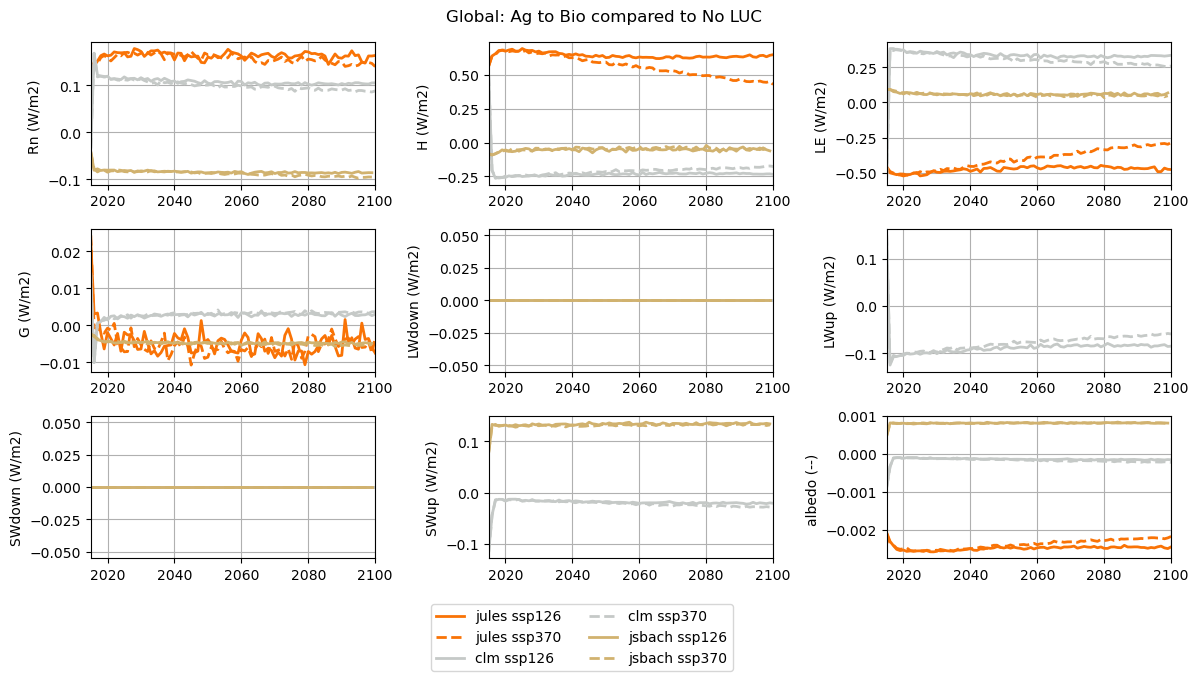

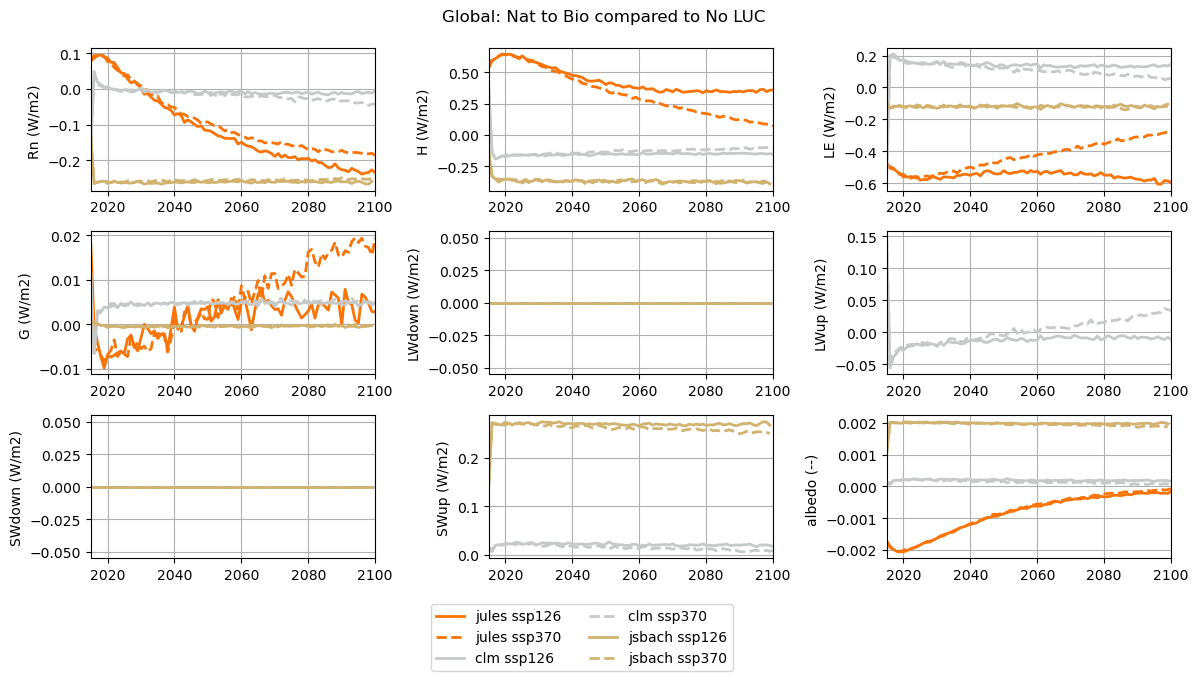

In [32]:

years = np.arange(2015,2101)     
nyears = len(years)
variable_exists['TotalAlbedo']['jsbach'] = True
variable_exists['TotalAlbedo']['clm'] = True

for landuse in LANDUSES:
    fig2,axes2=plt.subplots(3,3, figsize=[12,6])
    if landuse=='agtobio':
        fig2.suptitle('Global: Ag to Bio compared to No LUC',fontsize=12)
    elif landuse=='nattobio':
        fig2.suptitle('Global: Nat to Bio compared to No LUC',fontsize=12)
    icol=0
    irow=0
    for var in VARIABLES[0:9]:
        ax=axes2[irow,icol]
        #print(var,'is going in row ',irow,' and column ',icol)
        if var=='hfss': ax.set_ylabel('H (W/m2) ',fontsize=10)
        if var=='hfls': ax.set_ylabel('LE (W/m2) ',fontsize=10)
        if var=='hfg': ax.set_ylabel('G (W/m2) ',fontsize=10)
        if var=='rn': ax.set_ylabel('Rn (W/m2) ',fontsize=10)
        if var=='rsus': ax.set_ylabel('SWup (W/m2)',fontsize=10)
        if var=='rsds': ax.set_ylabel('SWdown (W/m2)',fontsize=10)
        if var=='rlus': ax.set_ylabel('LWup (W/m2)',fontsize=10)
        if var=='rlds': ax.set_ylabel('LWdown (W/m2)',fontsize=10)        
        if var=='TotalAlbedo': ax.set_ylabel('albedo (--) ',fontsize=10)
            
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        
        for model in MODELS: 
            if variable_exists[var][model]:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears      
                
                for ssp in SSPS:
                    print(var,model,ssp)    

                    plot_noluc=DELTA_GLOBAL[var][model][landuse][ssp]
                    ax.plot(years[:endyear], plot_noluc, label=model+' '+ssp,
                            c=colors[model],ls=linestyles[ssp],lw=2) 
        icol+=1
        if icol>2:
            icol=0
            irow+=1

    ax=axes2[0,1]
    handles,labels = ax.get_legend_handles_labels()
    fig2.legend(handles,labels,ncol=2,loc='upper left',bbox_to_anchor=(0.35, 0.0),fontsize=10)
    fig2.tight_layout()
    plt.savefig('/bdd/ESM2025/WP10/plots/biophys_fullplot_delta'+landuse+'.png', format="png")

In [33]:
variable_exists['rn']['clm'] = True
variable_exists['hfg']['jules'] = True
variable_exists['TotalAlbedo']['jsbach'] = True
variable_exists['TotalAlbedo']['clm'] = True

new plot: agtobio
new plot: nattobio


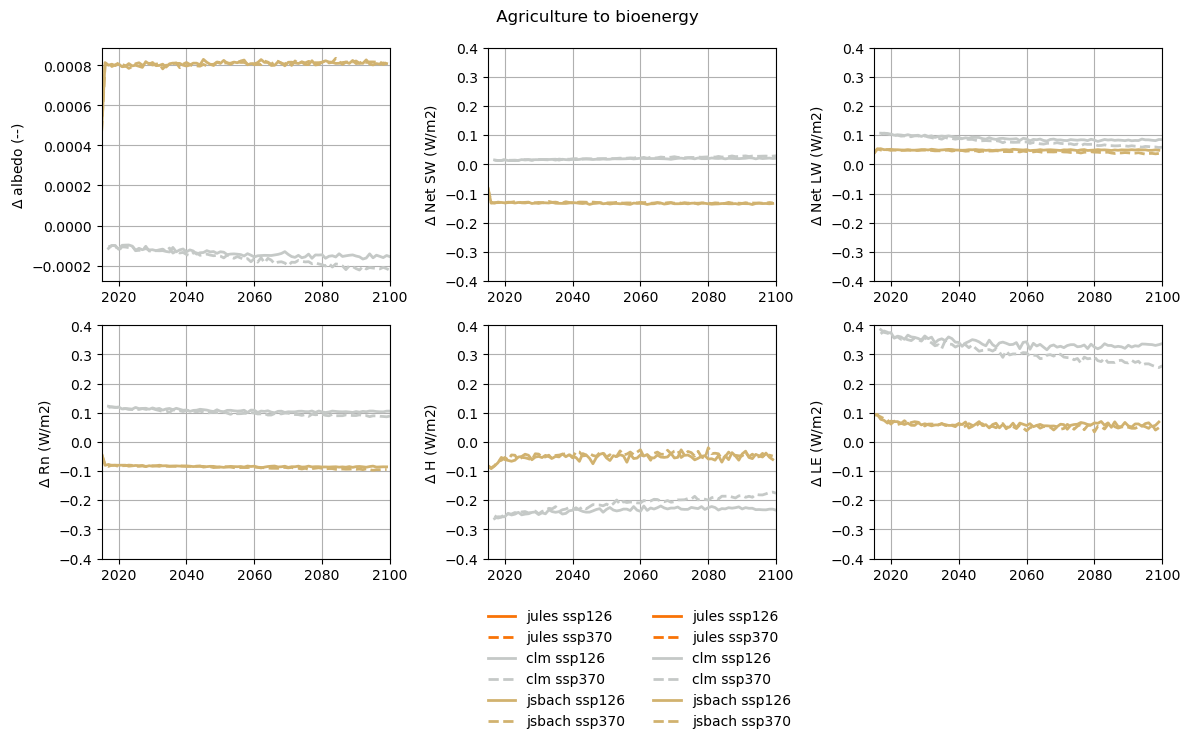

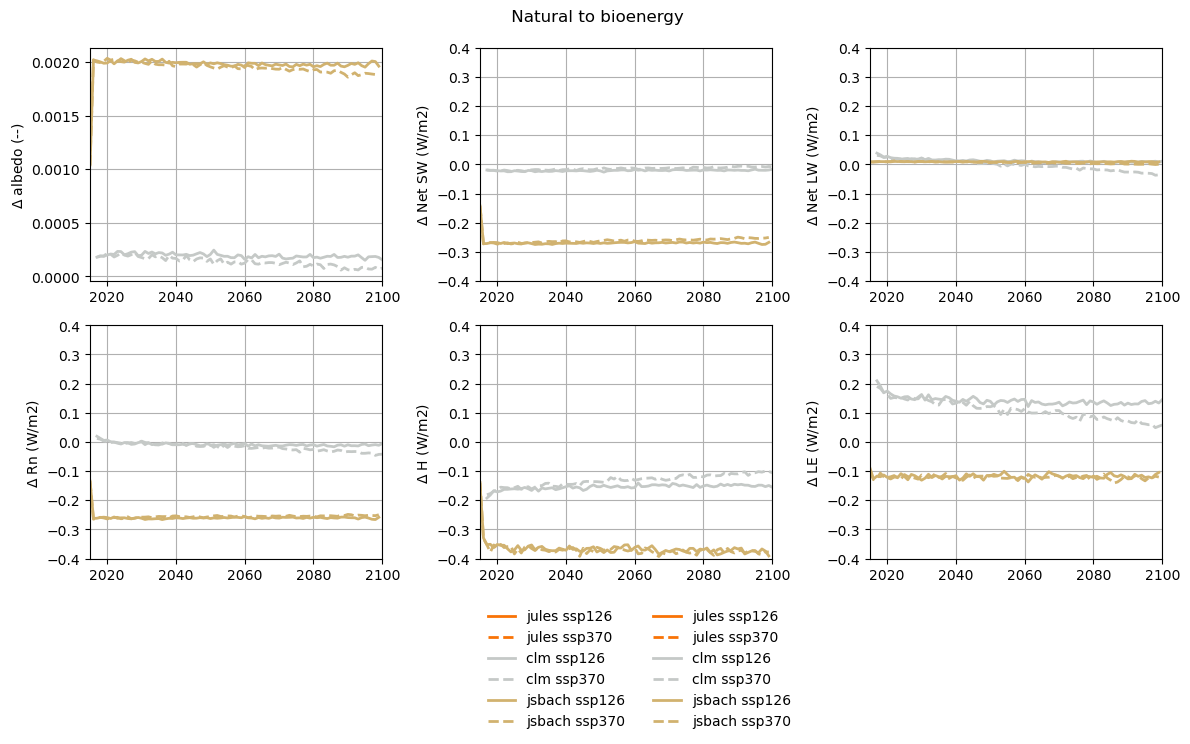

In [69]:
# READY TO MAKE THE FIGURE FOR THE PAPER NOW. 
# DELTA_GLOBAL ALREADY HAS THESE VARIABLES CALCULATED:
# VARIABLES=['rn','hfss','hfls',\
#           'hfg','rlds','rlus',\
#           'rsds','rsus','TotalAlbedo','SWnet','LWnet']

# PLOT THE LANDUSE SCENARIO DIFFERENCE FROM THE NOLUC SCENARIO

landuse_title=[' Agriculture to bioenergy', ' Natural to bioenergy']

# We don't need to plot all the same variables because some are the same
# regardless of the land use scenario (rlds and rsds).
# rlus is only available for one model, not interesting, and is a fx of tas
# 
PLOT_VARIABLES=['TotalAlbedo','SWnet','LWnet',\
           'rn',\
           'hfss','hfls']   

i1=0
for landuse in LANDUSES:
    #Set up plotting stuff
    #Each land use scenario has a new figure
    print('new plot:',landuse)
    fig2,axes2=plt.subplots(2,3, figsize=[12,6])
    fig2.suptitle(landuse_title[i1],fontsize=12)    
    irow=0
    icol=0
        
    for var in PLOT_VARIABLES:
        # set axes
        ax=axes2[irow,icol]
        if var=='hfss': ax.set_ylabel(r'$\Delta$ H (W/m2) ',fontsize=10)
        if var=='hfls': ax.set_ylabel(r'$\Delta$ LE (W/m2) ',fontsize=10)
        if var=='rn': ax.set_ylabel(r'$\Delta$ Rn (W/m2) ',fontsize=10)
        if var=='SWnet': ax.set_ylabel(r'$\Delta$ Net SW (W/m2)',fontsize=10)
        if var=='LWnet': ax.set_ylabel(r'$\Delta$ Net LW (W/m2)',fontsize=10)      
        if var=='TotalAlbedo': ax.set_ylabel(r'$\Delta$ albedo (--) ',fontsize=10)        
            
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        if var!='TotalAlbedo':
            ax.set_ylim([-0.4,0.4])
        
        for model in MODELS[1:]:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears

            for ssp in SSPS:
                plot_luc=DELTA_GLOBAL[var][model][landuse][ssp]
            
                if model=='clm':
                    ax.plot(years[2:endyear], plot_luc[2:], label=model+' '+ssp,
                            c=colors[model],ls=linestyles[ssp],lw=2)
                
                else:
                    ax.plot(years[:endyear], plot_luc, label=model+' '+ssp,
                            c=colors[model],ls=linestyles[ssp],lw=2)
                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)
                #if model=='jsbach' and ssp=='ssp126':
                #    if var=='rn' or var=='hfss' or var=='hfls':
                ##        print(ssp,var,plot_luc)
                #        if var=='rn':
                #            print(DELTA_GLOBAL['hfg'][model][landuse][ssp])
                #            print(' ')
                #            print(DELTA_GLOBAL['LWnet'][model][landuse][ssp] + DELTA_GLOBAL['SWnet'][model][landuse][ssp])
                
        icol+=1
        if icol>2:
            icol=0
            irow+=1
                    
    i1+=1

    ax=axes[0,0]
    handles2,labels2 = ax.get_legend_handles_labels()
    fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.40, 0.00),\
                    frameon=False,fontsize=10)
    fig2.tight_layout()
    plt.savefig('/bdd/ESM2025/WP10/plots/biophys_delta'+landuse+'.png', format="png")

new plot: agtobio TotalAlbedo
agtobio TotalAlbedo clm ssp126 nan nan
agtobio TotalAlbedo clm ssp370 nan nan
agtobio TotalAlbedo jsbach ssp126 nan nan
agtobio TotalAlbedo jsbach ssp370 nan nan
save the plot: /bdd/ESM2025/WP10/maps/mapdelta_agtobio_TotalAlbedo.png
new plot: agtobio hfss
agtobio hfss clm ssp126 -1.5964448064455834 0.7738591300116644
agtobio hfss clm ssp370 -1.2815471374412681 0.8700626863373652
agtobio hfss jsbach ssp126 0.0 0.0
agtobio hfss jsbach ssp370 0.0 0.0
save the plot: /bdd/ESM2025/WP10/maps/mapdelta_agtobio_hfss.png
new plot: agtobio hfls
agtobio hfls clm ssp126 -0.7709728969468014 2.5068278304732696
agtobio hfls clm ssp370 -0.9359535733858747 1.9966869831085206
agtobio hfls jsbach ssp126 0.0 0.0
agtobio hfls jsbach ssp370 0.0 0.0
save the plot: /bdd/ESM2025/WP10/maps/mapdelta_agtobio_hfls.png
new plot: nattobio TotalAlbedo
nattobio TotalAlbedo clm ssp126 nan nan
nattobio TotalAlbedo clm ssp370 nan nan
nattobio TotalAlbedo jsbach ssp126 nan nan
nattobio TotalAlb

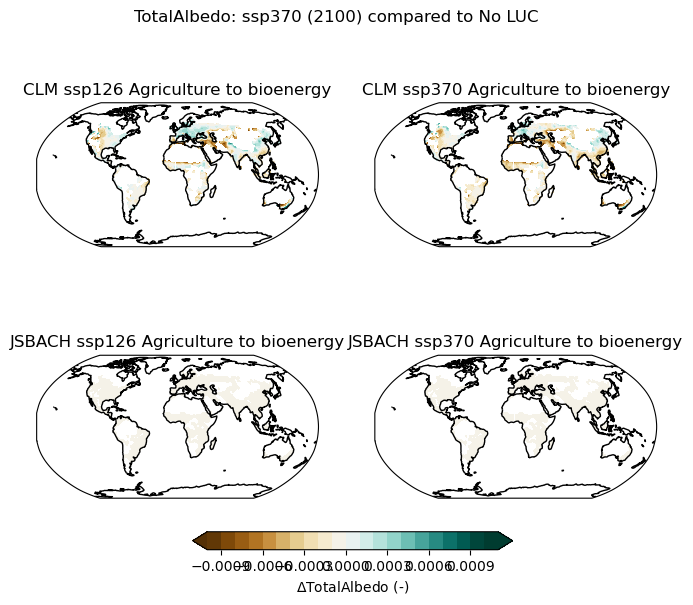

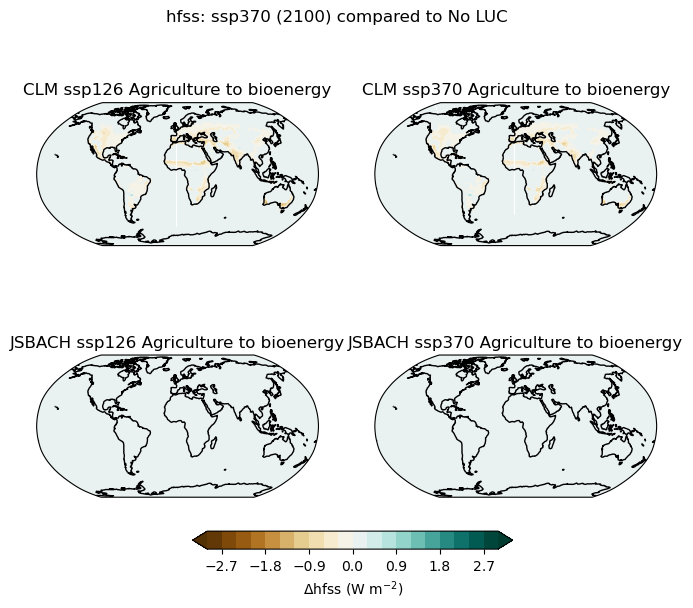

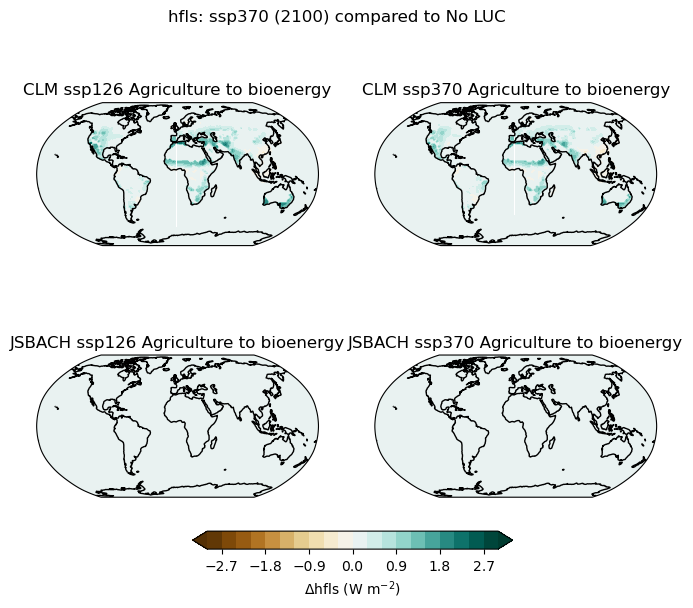

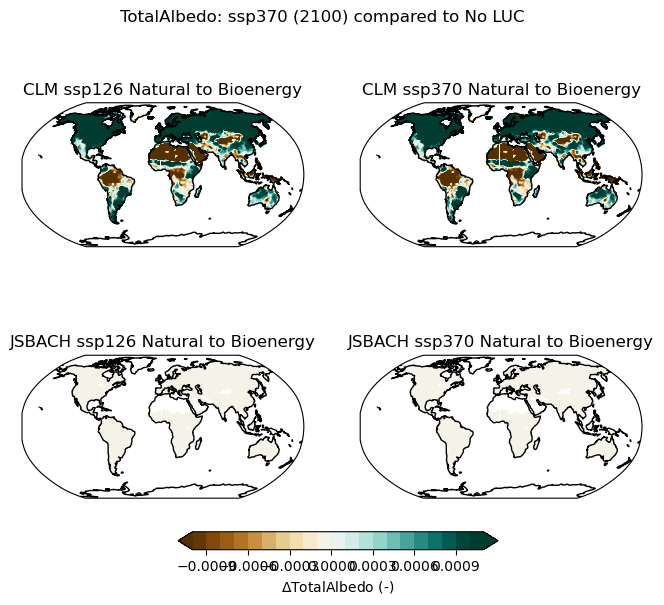

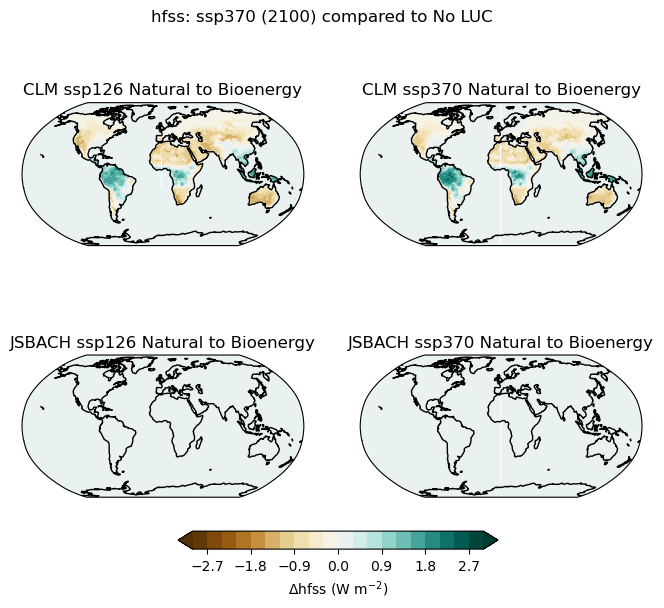

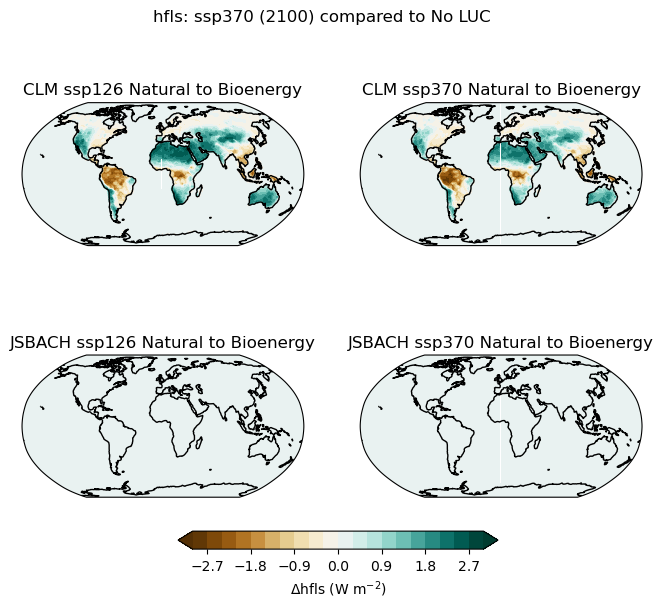

In [75]:
#Same as above but make maps now.
lsm_name=['CLM','JSBACH','JULES']
landuse_name=['Agriculture to bioenergy', \
              'Natural to Bioenergy']
PLOT_VARIABLES=['TotalAlbedo','hfss','hfls'] 
i1=0
for landuse in LANDUSES:
    #Set up plotting stuff
    #Each land use scenario has a new figure

    irow=0
    icol=0
    for var in PLOT_VARIABLES:
        # set axes
        if var=='hfss': ax.set_ylabel(r'$\Delta$ H (W/m2) ',fontsize=10)
        if var=='hfls': ax.set_ylabel(r'$\Delta$ LE (W/m2) ',fontsize=10)
        if var=='rn': ax.set_ylabel(r'$\Delta$ Rn (W/m2) ',fontsize=10)
        if var=='SWnet': ax.set_ylabel(r'$\Delta$ Net SW (W/m2)',fontsize=10)
        if var=='LWnet': ax.set_ylabel(r'$\Delta$ Net LW (W/m2)',fontsize=10)      
        if var=='TotalAlbedo': ax.set_ylabel(r'$\Delta$ albedo (--) ',fontsize=10)        

        pltname='/bdd/ESM2025/WP10/maps/mapdelta_'+landuse+'_'+var+'.png'
        print('new plot:',landuse,var)
        fig3,axes3=plt.subplots(nrows=2,ncols=2,
                                subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                                figsize=(8,6))  
        axes3=axes3.flatten()        
        fig3.suptitle(landuse_name[i1],fontsize=12)    
        
        ax_ind=0
        i0=0
        for model in MODELS[1:]:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears

            land_fraction,lons,lats = get_lsm_data(model)
            for ssp in SSPS:
                maparray = MAP_DELTA_2100[var][model][landuse][ssp]
                print(landuse,var,model,ssp,np.min(maparray),np.max(maparray))
                cs = make_map(var,lsm_name[i0],ssp,landuse_name[i1],axes3,ax_ind,
                              np.array(lons),np.array(lats),maparray,mask_between=True)
                ax_ind+=1
            i0+=1
            
        cbar_ax = fig3.add_axes([0.32, 0.08, 0.4, 0.03])                        
        # Draw the colorbar
        if var=='TotalAlbedo':
            cbar=fig3.colorbar(cs, cax=cbar_ax,  
                        orientation='horizontal', 
                        label=r'$\Delta$'+var+' (-)')
        else:
            cbar=fig3.colorbar(cs, cax=cbar_ax,  
                        orientation='horizontal', 
                        label=r'$\Delta$'+var+' (W m$^{-2}$)')
        #fig3.tight_layout()
        print('save the plot:',pltname)
        plt.suptitle(var+': '+ssp+' (2100) compared to No LUC')
        plt.savefig(pltname,format="png", dpi=400)    
        #plt.close()
        del(cs,fig3,axes3)
    i1+=1